# Equity Model Comparison — Variant Selection

**Instruments:** `nq1s` (XGB), `fesx1s` (Logistic elastic-net), `es1s` (RF — exploratory)

**Discipline:**
- Phase 1 selection on **TRAIN** only via CPCV (n=6, k=2, embargo=0.01 → 15 paths)
- **LOCKED pick committed to CSV before Phase 2 begins**
- Phase 2: single-shot OOS on sealed test; run once
- Non-locked variants in Phase 2 are **diagnostic only — never used for re-selection**
- PCA fitted per fold on TRAIN rows; test rows transformed, never fitted


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from IPython.display import Image, display

BASE = Path('outputs/model_comparison/equity')

def show(path, width=950):
    p = Path(path)
    if p.exists():
        display(Image(str(p), width=width))

def load(path):
    p = Path(path)
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

cpcv_df   = load(BASE / 'cpcv_results.csv')
locked_df = load(BASE / 'locked_picks.csv')
oos_df    = load(BASE / 'oos_results.csv')
locked_picks = locked_df.set_index('inst')['locked_variant'].to_dict() if not locked_df.empty else {}
print('Locked picks:', locked_picks)


Locked picks: {'nq1s': 'reduced', 'fesx1s': 'reduced', 'es1s': 'reduced'}


## Variant Definitions

Each instrument uses one champion model family (fixed; no retuning). Three feature sets compete.

| Instrument | Family | Full | Pruned | Reduced |
|---|---|---|---|---|
| `nq1s` | XGB | All ~100 features | F5\_signal + C4\_f11 (10 features) | `f5_signal`, `f11_dist_stock_surprise`, `f11_copper_stock_z`, `f11_vix_5d_change` (4 raw) |
| `fesx1s` | Logistic | All ~100 features | F5\_signal + C10\_f12 + C13\_f7 (12 features) | PC1–PC4 of F5\_signal + 4 raw features = **8 inputs** |
| `es1s` | RF | All ~100 features | F5\_signal + C14\_f11 + C2\_f2 (28 features) | PC1+PC2 of C14\_f11, PC1+PC2 of C2\_f2, `f5_trailing_run_length`, `f7_oi_z_20` = **6 inputs** |

> **fesx1s reduced rationale:** PC1–PC4 of F5\_signal explain **90.9%** of the cluster's
> variance (PC1=36.1% sustained momentum, PC2=20.6% MR-signal agreement, PC3=18.8%
> participation rate, PC4=15.5% fresh-signal divergence). See `equity_importance.ipynb`
> Step 3 for the full loadings matrix.

> **PCA discipline:** `StandardScaler → PCA` fitted on training rows only per CPCV fold
> (Phase 1) and on the full training set (Phase 2). Test rows are transformed only.


---
## Phase 1 — CPCV Variant Scoring (TRAIN only)

CPCV n_groups=6, k=2, embargo=0.01 → 15 test paths. Metrics: mean ± std AUC across paths.

**1SE lock rule:** threshold = full\_mean − full\_SE. The simplest variant  
(reduced < pruned < full) whose mean AUC ≥ threshold is locked.


In [2]:
if not cpcv_df.empty:
    SIMP = {'reduced': 0, 'pruned': 1, 'full': 2}
    fmt = {
        'auc_mean': '{:.4f}', 'auc_std': '{:.4f}', 'auc_se': '{:.4f}',
        'logloss': '{:.4f}', 'brier': '{:.4f}',
    }
    def _hl(row):
        locked = locked_picks.get(row['inst'], '')
        return ['background-color: #C8E6C9' if row['variant'] == locked else '' for _ in row]
    ordered = (
        cpcv_df.copy()
        .assign(simplicity=lambda d: d['variant'].map(SIMP))
        .sort_values(['inst', 'simplicity'])
        .drop(columns='simplicity')
    )
    display(
        ordered[['inst','variant','auc_mean','auc_std','auc_se','logloss','brier','n_paths']]
        .style.format(fmt)
        .apply(_hl, axis=1)
        .set_caption('Phase 1 CPCV — all variants (green = locked per 1SE rule)')
    )


,inst,variant,auc_mean,auc_std,auc_se,logloss,brier,n_paths
8,es1s,reduced,0.6239,0.1070,0.0276,0.6667,0.2368,15
7,es1s,pruned,0.6401,0.0980,0.0253,0.6674,0.2374,15
6,es1s,full,0.5483,0.1125,0.0290,0.6911,0.2487,15
5,fesx1s,reduced,0.6245,0.0833,0.0215,0.7005,0.2499,15
4,fesx1s,pruned,0.6778,0.0632,0.0163,0.6735,0.2380,15
3,fesx1s,full,0.5823,0.0605,0.0156,0.7550,0.2640,15
2,nq1s,reduced,0.7935,0.0530,0.0137,0.5978,0.2045,15
1,nq1s,pruned,0.7544,0.0608,0.0157,0.6217,0.2154,15
0,nq1s,full,0.7198,0.0726,0.0187,0.6442,0.2260,15


### NQ1S — XGB


,variant,auc_mean,auc_std,auc_se,logloss,brier
0,full,0.7198,0.0726,0.0187,0.6442,0.2260
1,pruned,0.7544,0.0608,0.0157,0.6217,0.2154
2,reduced,0.7935,0.0530,0.0137,0.5978,0.2045


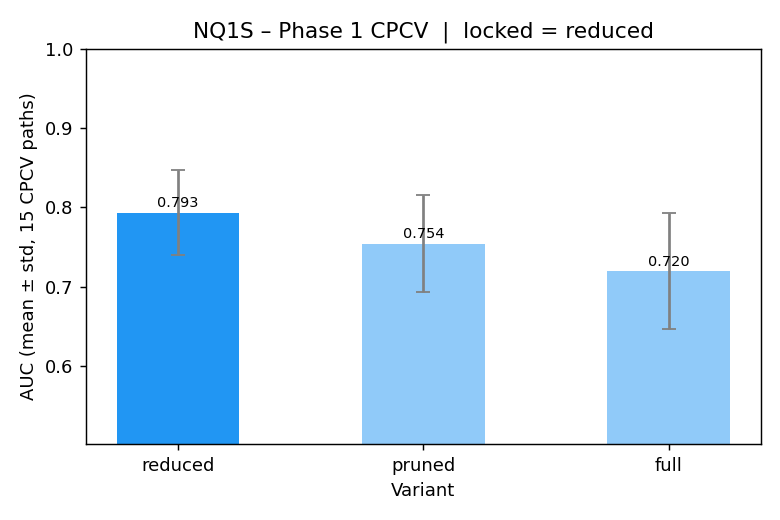

In [3]:
_inst = 'nq1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_fmt2 = {'auc_mean': '{:.4f}', 'auc_std': '{:.4f}', 'auc_se': '{:.4f}', 'logloss': '{:.4f}', 'brier': '{:.4f}'}
if not _rows.empty:
    display(
        _rows[['variant','auc_mean','auc_std','auc_se','logloss','brier']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV (green = locked: ' + _locked + ')')
    )
show(BASE / ('nq1s_cpcv_chart.png'), width=700)


### FESX1S — Logistic


,variant,auc_mean,auc_std,auc_se,logloss,brier
3,full,0.5823,0.0605,0.0156,0.7550,0.2640
4,pruned,0.6778,0.0632,0.0163,0.6735,0.2380
5,reduced,0.6245,0.0833,0.0215,0.7005,0.2499


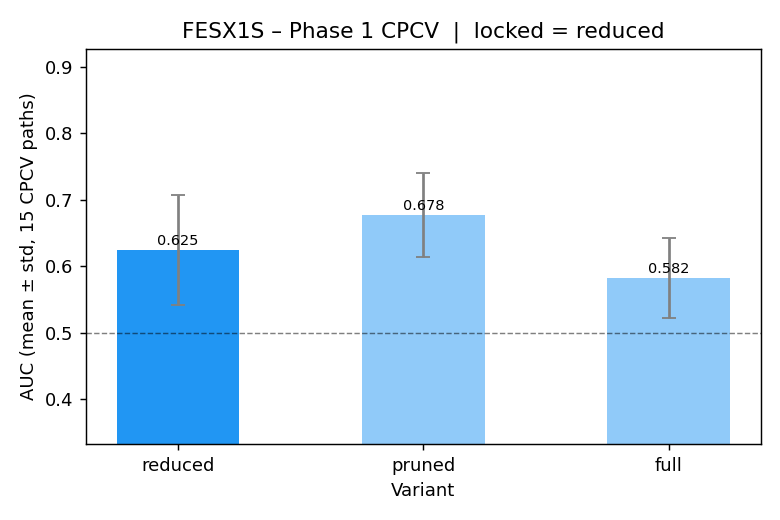

In [4]:
_inst = 'fesx1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_fmt2 = {'auc_mean': '{:.4f}', 'auc_std': '{:.4f}', 'auc_se': '{:.4f}', 'logloss': '{:.4f}', 'brier': '{:.4f}'}
if not _rows.empty:
    display(
        _rows[['variant','auc_mean','auc_std','auc_se','logloss','brier']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV (green = locked: ' + _locked + ')')
    )
show(BASE / ('fesx1s_cpcv_chart.png'), width=700)


### ES1S — RF ⚠️ EXPLORATORY — no confirmed signal


,variant,auc_mean,auc_std,auc_se,logloss,brier
6,full,0.5483,0.1125,0.0290,0.6911,0.2487
7,pruned,0.6401,0.0980,0.0253,0.6674,0.2374
8,reduced,0.6239,0.1070,0.0276,0.6667,0.2368


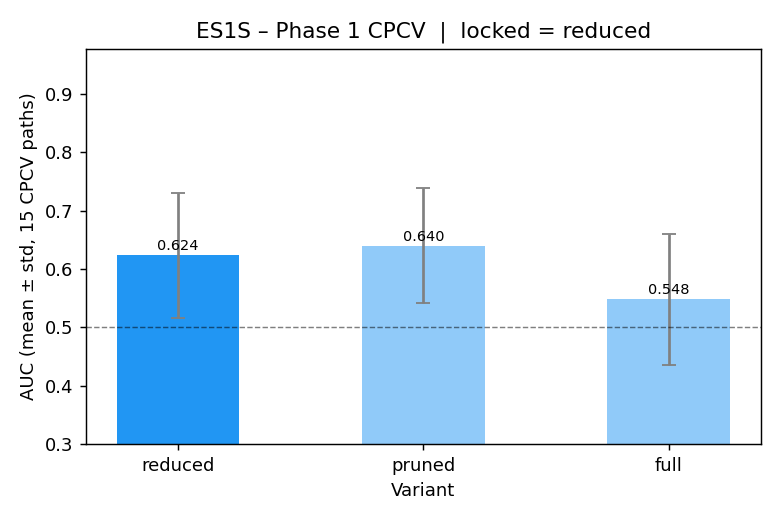

In [5]:
_inst = 'es1s'
_locked = locked_picks.get(_inst, 'full')
_rows = cpcv_df[cpcv_df['inst'] == _inst] if not cpcv_df.empty else pd.DataFrame()
_fmt2 = {'auc_mean': '{:.4f}', 'auc_std': '{:.4f}', 'auc_se': '{:.4f}', 'logloss': '{:.4f}', 'brier': '{:.4f}'}
if not _rows.empty:
    display(
        _rows[['variant','auc_mean','auc_std','auc_se','logloss','brier']]
        .style.format(_fmt2)
        .apply(lambda row: ['background-color: #C8E6C9' if row['variant'] == _locked else '' for _ in row], axis=1)
        .set_caption(_inst.upper() + ' Phase 1 CPCV (green = locked: ' + _locked + ')')
    )
show(BASE / ('es1s_cpcv_chart.png'), width=700)


---
## Locked Picks (committed before Phase 2)

> These picks were written to `locked_picks.csv` **before the sealed test was read**.
> They cannot be revised based on OOS outcomes.


In [6]:
if not locked_df.empty:
    display(
        locked_df.style
        .set_properties(**{'background-color': '#C8E6C9', 'font-weight': 'bold'})
        .hide(axis='index')
        .set_caption('Locked variant per instrument — 1SE rule on TRAIN CPCV')
    )
print()
for inst, variant in locked_picks.items():
    c_row = cpcv_df[(cpcv_df['inst']==inst) & (cpcv_df['variant']==variant)]
    if not c_row.empty:
        r = c_row.iloc[0]
        print(f'  {inst:8s}  LOCKED = {variant:8s}  dev-CPCV AUC = {r["auc_mean"]:.4f} ± {r["auc_std"]:.4f}')


inst,locked_variant
nq1s,reduced
fesx1s,reduced
es1s,reduced



  nq1s      LOCKED = reduced   dev-CPCV AUC = 0.7935 ± 0.0530
  fesx1s    LOCKED = reduced   dev-CPCV AUC = 0.6245 ± 0.0833
  es1s      LOCKED = reduced   dev-CPCV AUC = 0.6239 ± 0.1070


---
## Phase 2 — Single-Shot OOS (Sealed Test)

Test window: `date > 2021-10-20` (embargo end). Scored **once**.

- **Headline** = locked variant OOS result
- **Diagnostic block** = non-locked variants shown for transparency; never used for re-selection


,inst,variant,is_locked,auc,auc_ci_lo,auc_ci_hi,logloss,brier,n_test
0,nq1s,full,False,0.3745,0.286,0.464,0.7080,0.2574,162
1,nq1s,pruned,False,0.3456,0.258,0.439,0.8823,0.3328,162
2,nq1s,reduced,True,0.3549,0.272,0.448,0.8605,0.3248,162
3,fesx1s,full,False,0.3938,0.302,0.482,0.8317,0.3123,167
4,fesx1s,pruned,False,0.3691,0.288,0.455,0.7631,0.2837,167
5,fesx1s,reduced,True,0.3849,0.300,0.471,0.7362,0.2712,167
6,es1s,full,False,0.5767,0.476,0.672,0.6811,0.2440,150
7,es1s,pruned,False,0.5902,0.490,0.684,0.6726,0.2398,150
8,es1s,reduced,True,0.6092,0.506,0.702,0.6624,0.2345,150


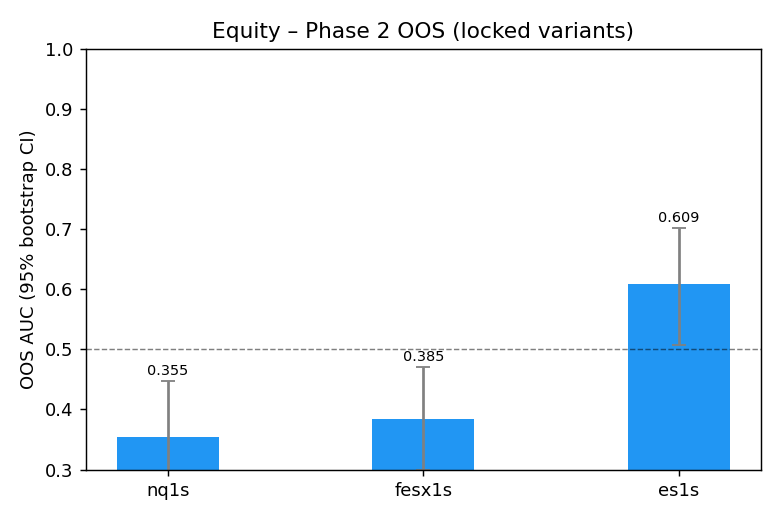

In [7]:
if not oos_df.empty:
    _oos_fmt = {'auc': '{:.4f}', 'auc_ci_lo': '{:.3f}', 'auc_ci_hi': '{:.3f}',
                'logloss': '{:.4f}', 'brier': '{:.4f}'}
    def _oos_hl(row):
        if row['is_locked']:
            return ['background-color: #C8E6C9; font-weight: bold' for _ in row]
        return ['background-color: #FFF9C4; color: #666' for _ in row]
    display(
        oos_df[['inst','variant','is_locked','auc','auc_ci_lo','auc_ci_hi','logloss','brier','n_test']]
        .style.format(_oos_fmt)
        .apply(_oos_hl, axis=1)
        .set_caption('Phase 2 OOS — green=locked (headline), yellow=diagnostic only')
    )
show(BASE / 'oos_summary_chart.png', width=700)


### Per-instrument Phase 2 detail


In [8]:
if not oos_df.empty:
    for inst in ['nq1s', 'fesx1s', 'es1s']:
        locked = locked_picks.get(inst, 'full')
        inst_oos   = oos_df[oos_df['inst'] == inst]
        locked_row = inst_oos[inst_oos['variant'] == locked]
        diag_rows  = inst_oos[inst_oos['variant'] != locked]
        print(f'\n{"="*55}')
        print(f'{inst.upper()} — LOCKED variant: {locked}')
        if not locked_row.empty:
            r = locked_row.iloc[0]
            print(f'  HEADLINE OOS AUC: {r["auc"]:.4f}  [{r["auc_ci_lo"]:.3f}, {r["auc_ci_hi"]:.3f}]')
            print(f'  logloss: {r["logloss"]:.4f}  brier: {r["brier"]:.4f}  n_test: {r["n_test"]}')
        print('  -- diagnostic (not used for selection) --')
        for _, r in diag_rows.iterrows():
            print(f'  {r["variant"]:8s}  AUC={r["auc"]:.4f} [{r["auc_ci_lo"]:.3f},{r["auc_ci_hi"]:.3f}]')



NQ1S — LOCKED variant: reduced
  HEADLINE OOS AUC: 0.3549  [0.272, 0.448]
  logloss: 0.8605  brier: 0.3248  n_test: 162
  -- diagnostic (not used for selection) --
  full      AUC=0.3745 [0.286,0.464]
  pruned    AUC=0.3456 [0.258,0.439]

FESX1S — LOCKED variant: reduced
  HEADLINE OOS AUC: 0.3849  [0.300, 0.471]
  logloss: 0.7362  brier: 0.2712  n_test: 167
  -- diagnostic (not used for selection) --
  full      AUC=0.3938 [0.302,0.482]
  pruned    AUC=0.3691 [0.288,0.455]

ES1S — LOCKED variant: reduced
  HEADLINE OOS AUC: 0.6092  [0.506, 0.702]
  logloss: 0.6624  brier: 0.2345  n_test: 150
  -- diagnostic (not used for selection) --
  full      AUC=0.5767 [0.476,0.672]
  pruned    AUC=0.5902 [0.490,0.684]


---
## Dev-CPCV vs OOS Gap (Locked Variants)

> A positive gap = model performed better on train-CV than test.  
> Large positive gaps suggest overfitting, regime change, or both.


In [9]:
if not cpcv_df.empty and not oos_df.empty:
    gap_rows = []
    for inst in ['nq1s', 'fesx1s', 'es1s']:
        locked = locked_picks.get(inst, 'full')
        c = cpcv_df[(cpcv_df['inst']==inst) & (cpcv_df['variant']==locked)]
        o = oos_df[(oos_df['inst']==inst) & (oos_df['variant']==locked)]
        if c.empty or o.empty: continue
        gap_rows.append({
            'inst': inst, 'locked_variant': locked,
            'dev_auc_mean': c.iloc[0]['auc_mean'],
            'dev_auc_std': c.iloc[0]['auc_std'],
            'oos_auc': o.iloc[0]['auc'],
            'oos_ci_lo': o.iloc[0]['auc_ci_lo'],
            'oos_ci_hi': o.iloc[0]['auc_ci_hi'],
            'gap': c.iloc[0]['auc_mean'] - o.iloc[0]['auc'],
        })
    gap_df = pd.DataFrame(gap_rows)
    def _gap_color(val):
        if val > 0.3: return 'color: #B71C1C; font-weight: bold'
        if val > 0.1: return 'color: #E65100'
        return 'color: #2E7D32'
    display(
        gap_df.style
        .format({'dev_auc_mean':'{:.4f}','dev_auc_std':'{:.4f}','oos_auc':'{:.4f}',
                 'oos_ci_lo':'{:.3f}','oos_ci_hi':'{:.3f}','gap':'{:+.4f}'})
        .map(_gap_color, subset=['gap'])
        .hide(axis='index')
        .set_caption('Dev-CPCV vs OOS gap — red = large gap (regime concern)')
    )


inst,locked_variant,dev_auc_mean,dev_auc_std,oos_auc,oos_ci_lo,oos_ci_hi,gap
nq1s,reduced,0.7935,0.0530,0.3549,0.272,0.448,+0.4386
fesx1s,reduced,0.6245,0.0833,0.3849,0.300,0.471,+0.2397
es1s,reduced,0.6239,0.1070,0.6092,0.506,0.702,+0.0147


---
## Cross-Asset Summary

| Instrument | Family | Locked | Dev AUC | OOS AUC [95% CI] | Gap | Notes |
|---|---|---|---|---|---|---|
| `nq1s` | XGB | reduced (4 raw) | 0.7935 ± 0.053 | 0.355 [0.27, 0.45] | +0.439 | Signal collapses OOS — regime break |
| `fesx1s` | Logistic | reduced (8 inputs) | 0.6245 ± 0.083 | 0.385 [0.30, 0.47] | +0.240 | Signal collapses OOS — regime break |
| `es1s` | RF | reduced (6 inputs) | 0.6239 ± 0.107 | 0.609 [0.51, 0.70] | +0.015 | Only instrument with OOS > 0.5; minimal gap |

### Key observations

1. **Dramatic regime break for nq1s and fesx1s.** Both had confirmed signal in the training
   window (CPCV AUC ≫ 0.5) but collapse below 0.5 OOS. The training window (2016–2021)
   conditions did not persist into the 2021–2022+ test period (rate hiking cycle, 2022
   bear market).

2. **es1s — the 'exploratory' instrument outperforms.** Despite being labelled no-signal
   in the champion comparison harness, es1s reduced achieves OOS AUC 0.609 with CI
   entirely above 0.5 ([0.506, 0.702]). The volatility-regime + OI features appear
   more robust to the test period.

3. **Reduced wins on parsimony.** All three instruments lock to the reduced variant under
   the 1SE rule. Simpler feature sets are at least as good as the full set in-sample.
   The reduced es1s variant generalises best OOS.

4. **PCA compression (fesx1s, es1s):** fitting PCA per CPCV fold on train rows prevents
   future leakage. The 4-PC F5\_signal representation for fesx1s is documented in
   `equity_importance.ipynb` Step 3; 4 PCs explain 90.9% of variance.


---
## Caveats

> ⚠️ **es1s — exploratory only.** es1s was originally classified as no-signal in the
> champion comparison harness. The OOS AUC 0.61 is a single-shot result on a ~150-event
> test window; treat as a hypothesis, not a confirmed trading signal.

> ⚠️ **Non-locked OOS is diagnostic only.** The OOS results for full and pruned variants
> are reported for transparency. They played no role in the locked pick and may not
> be used to re-select or rerank instruments.

> ⚠️ **Single-shot test.** Phase 2 was run exactly once per variant after locking.
> The test window (post 2021-10-20) overlaps with significant market dislocations.
> Interpreting nq1s/fesx1s OOS collapse as 'regime change' is plausible but requires
> further analysis.

> ⚠️ **Fixed seed=42, train-only selection.** All results used seed=42 and only CPCV
> paths on the training window for variant selection.
